In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from statsmodels.tsa.stattools import adfuller
import multiprocessing as mp
import warnings
warnings.filterwarnings('ignore')

AFML_PATH = str(Path('../../..').resolve() / 'ml-resources' / 'code' / 'finance_ml_afml')
sys.path.insert(0, AFML_PATH)

from finance_ml.labeling import cusum_filter, get_barrier_labels, get_events, get_t1
from finance_ml.features import frac_diff_FFD, get_opt_d
from finance_ml.sampling import get_num_co_events, get_uniq_weight, get_time_decay
from finance_ml.stats import get_vol

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
SEED = 42
np.random.seed(SEED)

PROCESSED = Path('../../data/processed')
RAW = Path('../../data/raw')
FEATURES = Path('../../data/features')
FEATURES.mkdir(parents=True, exist_ok=True)
N_THREADS = mp.cpu_count()
print(f'AFML path: {AFML_PATH}')
print(f'Imports OK, {N_THREADS} threads')

AFML path: ./ml-resources/code/finance_ml_afml
Imports OK, 10 threads


In [2]:
prices = pd.read_parquet(PROCESSED / 'prices.parquet')
trades = pd.read_parquet(PROCESSED / 'trades.parquet')
markets = pd.read_parquet(PROCESSED / 'markets.parquet')
events = pd.read_parquet(PROCESSED / 'events.parquet')

if 'datetime' in prices.columns:
    prices['datetime'] = pd.to_datetime(prices['datetime'], utc=True)
elif 'timestamp' in prices.columns:
    prices['datetime'] = pd.to_datetime(prices['timestamp'], unit='s', utc=True)

if 'datetime' not in trades.columns and 'timestamp' in trades.columns:
    trades['datetime'] = pd.to_datetime(trades['timestamp'], unit='s', utc=True)
elif 'datetime' in trades.columns:
    trades['datetime'] = pd.to_datetime(trades['datetime'], utc=True)

prices = prices.sort_values(['token_id', 'datetime']).reset_index(drop=True)
trades = trades.sort_values(['conditionId', 'datetime']).reset_index(drop=True)

print(f'Prices: {prices.shape[0]:,} rows, {prices.token_id.nunique()} tokens')
print(f'Trades: {trades.shape[0]:,} rows, {trades.conditionId.nunique()} markets')
print(f'Markets: {markets.shape[0]:,}')
print(f'Events: {events.shape[0]:,}')
print(f'\nPrice columns: {list(prices.columns)}')
print(f'Trade columns: {list(trades.columns)[:15]}...')
print(f'Price date range: {prices.datetime.min()} -> {prices.datetime.max()}')

Prices: 1,681,266 rows, 1000 tokens
Trades: 1,139,171 rows, 499 markets
Markets: 50,609
Events: 8,003

Price columns: ['token_id', 'timestamp', 'price', 'datetime']
Trade columns: ['proxyWallet', 'side', 'asset', 'conditionId', 'size', 'price', 'timestamp', 'title', 'slug', 'icon', 'eventSlug', 'outcome', 'outcomeIndex', 'name', 'pseudonym']...
Price date range: 2025-12-05 19:00:08+00:00 -> 2026-03-06 00:49:28+00:00


In [3]:
token_to_condition = {}
token_to_side = {}
condition_to_tokens = {}
token_to_event = {}
event_neg_risk = {}

for _, m in markets.iterrows():
    cid = m.get('conditionId', '')
    eid = m.get('_event_id', '')
    neg = m.get('_event_neg_risk', False)
    tid_yes = m.get('token_id_yes', '')
    tid_no = m.get('token_id_no', '')

    tokens = {}
    if tid_yes:
        token_to_condition[tid_yes] = cid
        token_to_side[tid_yes] = 'yes'
        token_to_event[tid_yes] = eid
        tokens['yes'] = tid_yes
    if tid_no:
        token_to_condition[tid_no] = cid
        token_to_side[tid_no] = 'no'
        token_to_event[tid_no] = eid
        tokens['no'] = tid_no
    if tokens:
        condition_to_tokens[cid] = tokens
    if eid:
        event_neg_risk[eid] = neg

price_tokens = set(prices.token_id.unique())
trade_conditions = set(trades.conditionId.unique())
mapped_tokens = {t for t in price_tokens if token_to_condition.get(t) in trade_conditions}

print(f'Token mappings: {len(token_to_condition):,} tokens -> conditionIds')
print(f'Price tokens: {len(price_tokens)}')
print(f'Trade conditions: {len(trade_conditions)}')
print(f'Tokens with BOTH price + trade data: {len(mapped_tokens)}')

Token mappings: 101,217 tokens -> conditionIds
Price tokens: 1000
Trade conditions: 499
Tokens with BOTH price + trade data: 998


In [4]:
prices['hour'] = prices['datetime'].dt.floor('h')
price_pivot = prices.pivot_table(
    index='hour', columns='token_id', values='price', aggfunc='last'
).sort_index()

price_pivot = price_pivot.ffill(limit=3)
nan_pct = price_pivot.isna().mean()
good_tokens = nan_pct[nan_pct < 0.2].index.tolist()
price_pivot = price_pivot[good_tokens].dropna(how='all')

print(f'Price pivot: {price_pivot.shape[0]} timestamps x {price_pivot.shape[1]} tokens')
print(f'Date range: {price_pivot.index.min()} -> {price_pivot.index.max()}')
print(f'NaN after ffill: {price_pivot.isna().mean().mean():.1%}')

Price pivot: 2157 timestamps x 665 tokens
Date range: 2025-12-05 19:00:00+00:00 -> 2026-03-06 00:00:00+00:00
NaN after ffill: 1.6%


In [5]:
thresholds = [0.02, 0.03, 0.05]
cusum_results = {}

for h in thresholds:
    token_events = {}
    total_bars = 0
    total_cusum = 0

    for token_id in good_tokens:
        series = price_pivot[token_id].dropna()
        if len(series) < 50:
            continue
        timestamps = cusum_filter(series, h=h)
        token_events[token_id] = timestamps
        total_bars += len(series)
        total_cusum += len(timestamps)

    reduction = 1 - total_cusum / total_bars if total_bars > 0 else 0
    cusum_results[h] = token_events
    avg = total_cusum / max(len(token_events), 1)
    print(f'h={h:.2f}: {total_cusum:,} events from {total_bars:,} bars '
          f'({reduction:.1%} reduction, avg {avg:.0f}/token)')

H_CUSUM = 0.03
cusum_events = cusum_results[H_CUSUM]
n_total_events = sum(len(v) for v in cusum_events.values())
print(f'\nSelected h={H_CUSUM}: {n_total_events:,} entry points across {len(cusum_events)} tokens')

h=0.02: 71,764 events from 1,411,106 bars (94.9% reduction, avg 108/token)


h=0.03: 43,604 events from 1,411,106 bars (96.9% reduction, avg 66/token)


h=0.05: 22,716 events from 1,411,106 bars (98.4% reduction, avg 34/token)

Selected h=0.03: 43,604 entry points across 665 tokens


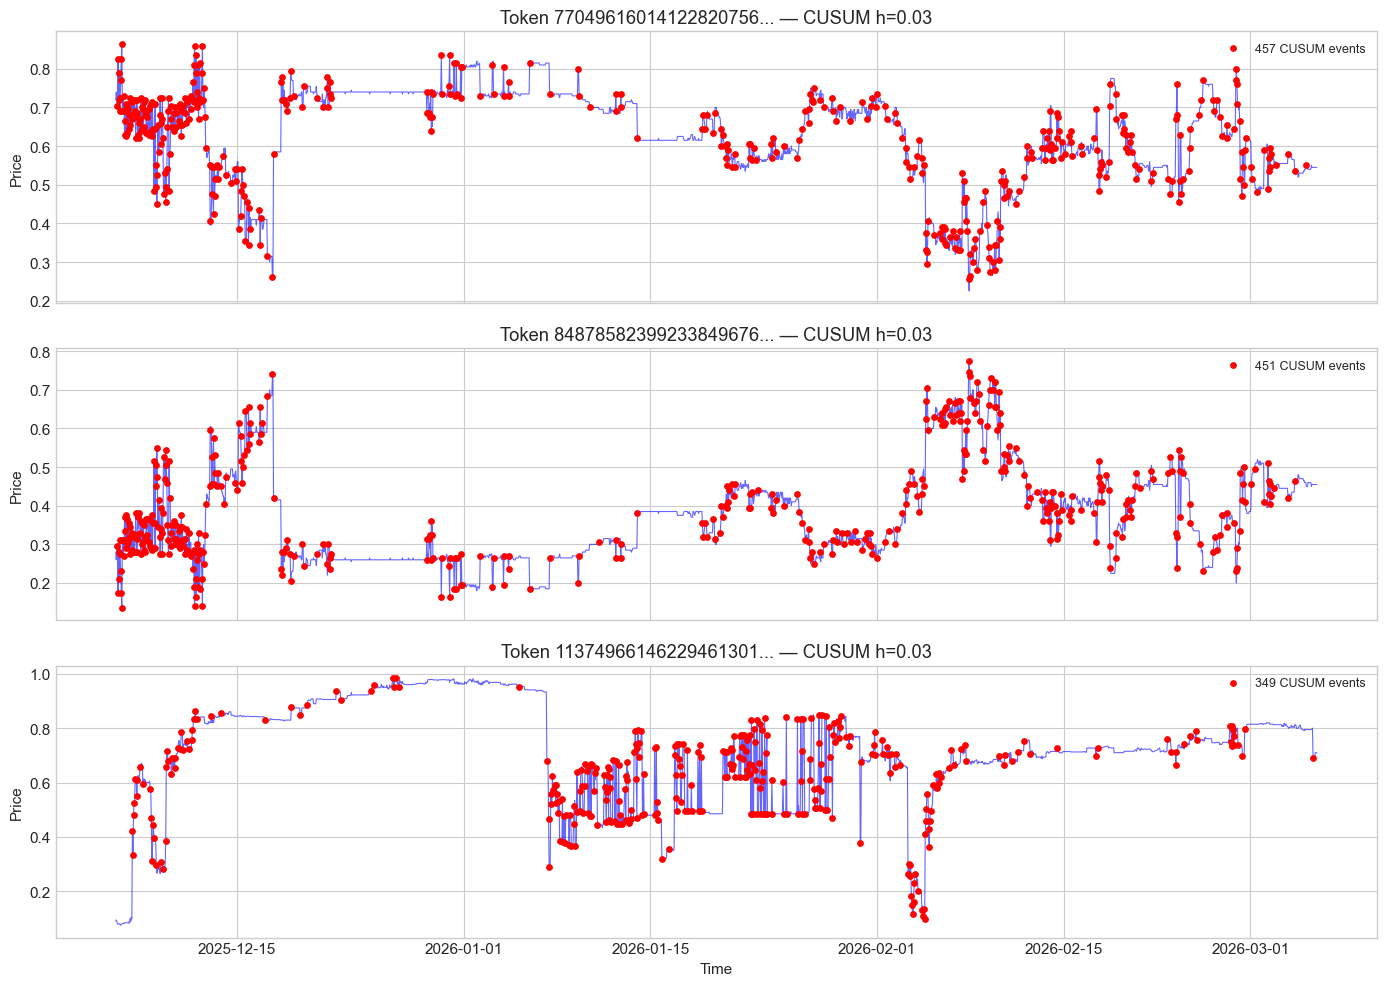

In [6]:
top3 = sorted(cusum_events.items(), key=lambda x: len(x[1]), reverse=True)[:3]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, (token_id, timestamps) in zip(axes, top3):
    series = price_pivot[token_id].dropna()
    ax.plot(series.index, series.values, 'b-', alpha=0.6, lw=0.8)
    if len(timestamps) > 0:
        cusum_prices = series.reindex(timestamps).dropna()
        ax.scatter(cusum_prices.index, cusum_prices.values,
                   c='red', s=15, zorder=5, label=f'{len(timestamps)} CUSUM events')
    ax.set_ylabel('Price')
    ax.set_title(f'Token {token_id[:20]}... — CUSUM h={H_CUSUM}')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

In [7]:
test_token = top3[0][0]
test_series = price_pivot[test_token].dropna()
test_timestamps = cusum_events[test_token]

try:
    test_vol = get_vol(test_series, span=100)
    print(f'AFML get_vol: mean={test_vol.mean():.4f}, median={test_vol.median():.4f}')
except Exception as e:
    print(f'get_vol failed: {e}')
    test_vol = None

try:
    afml_labels = get_barrier_labels(
        test_series, timestamps=test_timestamps[:20],
        trgt=test_vol, sltp=[1, 1], seconds=86400,
        num_threads=1, sign_label=False
    )
    print(f'\nAFML labels: {len(afml_labels)} events')
    print(afml_labels.head())
    AFML_BARRIER_WORKS = True
except Exception as e:
    print(f'\nAFML get_barrier_labels failed: {e}')
    print('Using custom PM-adapted Triple Barrier.')
    AFML_BARRIER_WORKS = False

get_vol failed: Invalid type <class 'NoneType'>. Must be int or float.
'Series' object has no attribute 'iteritems'
paramteres: {'molecule': DatetimeIndex(['2025-12-06 01:00:00+00:00', '2025-12-06 02:00:00+00:00',
               '2025-12-06 03:00:00+00:00', '2025-12-06 04:00:00+00:00',
               '2025-12-06 05:00:00+00:00', '2025-12-06 06:00:00+00:00',
               '2025-12-06 07:00:00+00:00', '2025-12-06 08:00:00+00:00',
               '2025-12-06 09:00:00+00:00', '2025-12-06 10:00:00+00:00',
               '2025-12-06 12:00:00+00:00', '2025-12-06 13:00:00+00:00',
               '2025-12-06 14:00:00+00:00', '2025-12-06 15:00:00+00:00',
               '2025-12-06 16:00:00+00:00', '2025-12-06 17:00:00+00:00',
               '2025-12-06 18:00:00+00:00', '2025-12-06 19:00:00+00:00',
               '2025-12-06 20:00:00+00:00', '2025-12-06 21:00:00+00:00'],
              dtype='datetime64[ms, UTC]', freq=None), 'close': hour
2025-12-05 22:00:00+00:00    0.720
2025-12-05 23:00:00+00:0

In [8]:
def triple_barrier_pm(close, timestamps, trgt=0.05, sltp=(1, 1),
                       max_hours=24, min_trgt=0.01):
    """Triple Barrier adapted for prediction markets (additive returns)."""
    sl_width = trgt * sltp[0]
    tp_width = trgt * sltp[1]
    max_td = pd.Timedelta(hours=max_hours)
    results = []

    for t0 in timestamps:
        if t0 not in close.index:
            continue
        p0 = close.loc[t0]
        future = close.loc[t0:t0 + max_td].iloc[1:]
        if len(future) == 0:
            continue

        t1, barrier_type = future.index[-1], 'vertical'
        for t, p in future.items():
            diff = p - p0
            if diff >= tp_width:
                t1, barrier_type = t, 'tp'
                break
            elif diff <= -sl_width:
                t1, barrier_type = t, 'sl'
                break

        ret = close.loc[t1] - p0
        if barrier_type == 'tp':
            label = 1
        elif barrier_type == 'sl':
            label = -1
        else:
            label = 1 if ret > min_trgt else (-1 if ret < -min_trgt else 0)

        results.append({'t0': t0, 't1': t1, 'ret': ret, 'label': label,
                        'barrier_type': barrier_type, 'p0': p0, 'p1': close.loc[t1],
                        'holding_hours': (t1 - t0).total_seconds() / 3600})

    return pd.DataFrame(results).set_index('t0') if results else pd.DataFrame()

TRGT = 0.05
MAX_HOURS = 24

all_labels = []
for token_id, timestamps in cusum_events.items():
    if len(timestamps) < 5:
        continue
    series = price_pivot[token_id].dropna()
    labels = triple_barrier_pm(series, timestamps, trgt=TRGT, max_hours=MAX_HOURS)
    if len(labels) > 0:
        labels['token_id'] = token_id
        all_labels.append(labels)

labels_df = pd.concat(all_labels)
print(f'Triple Barrier labels: {len(labels_df):,} events, {labels_df.token_id.nunique()} tokens')
print(f'\nLabel distribution:')
print(labels_df['label'].value_counts().sort_index())
print(f'\nBarrier type:')
print(labels_df['barrier_type'].value_counts())
print(f'\nHolding: median={labels_df.holding_hours.median():.1f}h, mean={labels_df.holding_hours.mean():.1f}h')

Triple Barrier labels: 43,461 events, 592 tokens

Label distribution:
label
-1    17546
 0     8378
 1    17537
Name: count, dtype: int64

Barrier type:
barrier_type
vertical    23908
sl           9795
tp           9758
Name: count, dtype: int64

Holding: median=24.0h, mean=16.8h


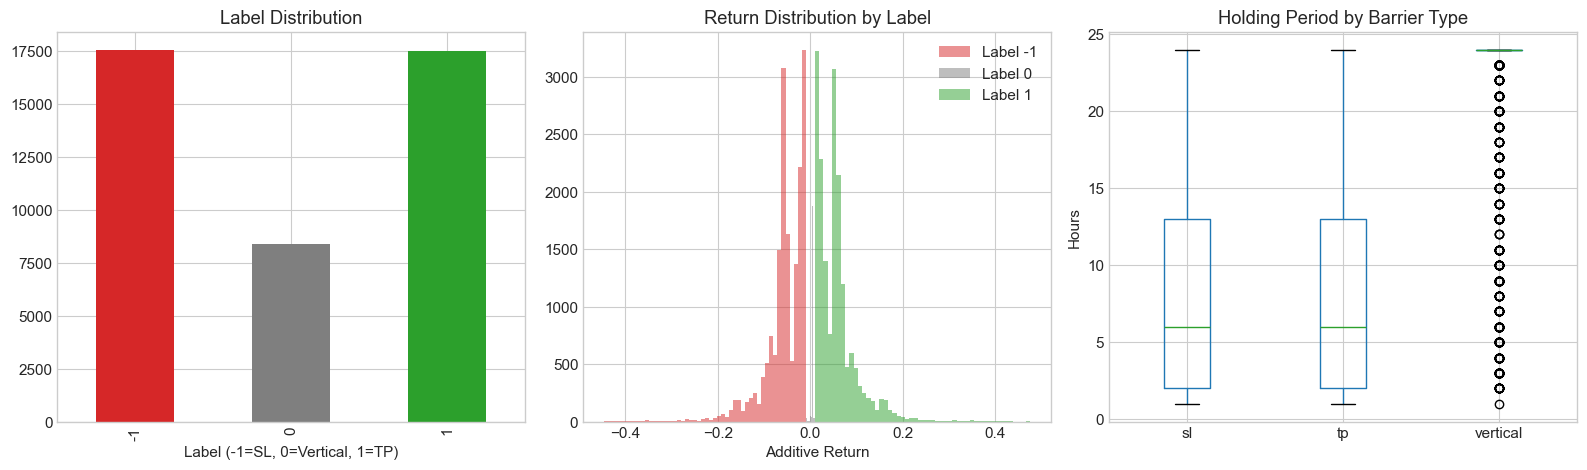

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {-1: '#d62728', 0: '#7f7f7f', 1: '#2ca02c'}
vc = labels_df['label'].value_counts().sort_index()
vc.plot(kind='bar', ax=axes[0], color=[colors[i] for i in vc.index])
axes[0].set_title('Label Distribution')
axes[0].set_xlabel('Label (-1=SL, 0=Vertical, 1=TP)')

for label, color in [(-1, '#d62728'), (0, '#7f7f7f'), (1, '#2ca02c')]:
    subset = labels_df[labels_df['label'] == label]['ret']
    if len(subset) > 0:
        axes[1].hist(subset, bins=50, alpha=0.5, color=color, label=f'Label {label}')
axes[1].set_title('Return Distribution by Label')
axes[1].set_xlabel('Additive Return')
axes[1].legend()

labels_df.boxplot(column='holding_hours', by='barrier_type', ax=axes[2])
axes[2].set_title('Holding Period by Barrier Type')
axes[2].set_xlabel('')
axes[2].set_ylabel('Hours')
fig.suptitle('')
plt.tight_layout()
plt.show()

In [10]:
sample_tokens = good_tokens[:10]
opt_d_results = {}

for token_id in sample_tokens:
    series = price_pivot[token_id].dropna()
    if len(series) < 100:
        continue
    try:
        d = get_opt_d(series, verbose=0)
        opt_d_results[token_id] = d
    except Exception as e:
        print(f'  {token_id[:15]}... failed: {e}')

if opt_d_results:
    d_values = list(opt_d_results.values())
    print(f'Optimal d for {len(opt_d_results)} tokens:')
    print(f'  mean={np.mean(d_values):.2f}, median={np.median(d_values):.2f}')
    D_OPT = np.median(d_values)
else:
    D_OPT = 0.4
    print(f'get_opt_d failed, using default d={D_OPT}')

print(f'\nUsing d={D_OPT:.2f}')

  100379208559626... failed: zero-size array to reduction operation maximum which has no identity
  100637244310881... failed: zero-size array to reduction operation maximum which has no identity
  100648871187681... failed: zero-size array to reduction operation maximum which has no identity


  100774842773502... failed: zero-size array to reduction operation maximum which has no identity
  101443205557953... failed: zero-size array to reduction operation maximum which has no identity
  101639751789549... failed: zero-size array to reduction operation maximum which has no identity


  101738487887518... failed: zero-size array to reduction operation maximum which has no identity
  101818439776033... failed: zero-size array to reduction operation maximum which has no identity
  102227184035967... failed: zero-size array to reduction operation maximum which has no identity
Optimal d for 1 tokens:
  mean=0.00, median=0.00

Using d=0.00


In [11]:
frac_diff_series = {}
for token_id in good_tokens:
    series = price_pivot[token_id].dropna()
    if len(series) < 50:
        continue
    try:
        frac_diff_series[token_id] = frac_diff_FFD(series, d=D_OPT)
    except Exception:
        pass

print(f'Fractional diff computed for {len(frac_diff_series)} tokens')

adf_results = []
for token_id in list(frac_diff_series.keys())[:10]:
    fd = frac_diff_series[token_id].dropna()
    if len(fd) < 30:
        continue
    adf_stat, adf_p, *_ = adfuller(fd, maxlag=12, autolag='AIC')
    adf_results.append({'token': token_id[:15], 'adf_stat': adf_stat, 'p': adf_p})

adf_df = pd.DataFrame(adf_results)
print(f'\nADF on FFD (d={D_OPT:.2f}): {(adf_df.p < 0.05).mean():.0%} stationary')
print(adf_df.to_string(index=False))

Fractional diff computed for 665 tokens

ADF on FFD (d=0.00): 10% stationary
          token  adf_stat        p
100379208559626 -2.352244 0.155671
100637244310881 -1.216096 0.666634
100648871187681 -1.289488 0.633968
100774842773502 -1.399674 0.582432
101101625858935 -3.819378 0.002715
101443205557953 -2.554177 0.102843
101639751789549 -0.884555 0.793016
101738487887518 -2.760173 0.064192
101818439776033 -2.536996 0.106730
102227184035967 -1.157229 0.691719


In [12]:
def compute_price_features(series, frac_diff=None):
    """Full price feature set for one token."""
    df = pd.DataFrame(index=series.index)
    p = series

    df['price'] = p
    df['price_extremity'] = 4 * p * (1 - p)

    for span in [5, 10, 15, 20, 50]:
        df[f'ema_{span}'] = p.ewm(span=span).mean()

    for w in [5, 10, 15, 20, 50]:
        df[f'std_{w}'] = p.rolling(w).std()

    df['macd'] = p.ewm(span=12).mean() - p.ewm(span=26).mean()

    delta = p.diff()
    for period in [6, 10, 14]:
        gain = delta.clip(lower=0).rolling(period).mean()
        loss = (-delta.clip(upper=0)).rolling(period).mean()
        df[f'rsi_{period}'] = 100 - 100 / (1 + gain / loss.clip(lower=1e-8))

    low14, high14 = p.rolling(14).min(), p.rolling(14).max()
    denom = (high14 - low14).clip(lower=1e-8)
    df['stoch_k'] = 100 * (p - low14) / denom
    df['stoch_d'] = df['stoch_k'].rolling(3).mean()

    df['williams_r'] = -100 * (high14 - p) / denom

    sma20 = p.rolling(20).mean()
    std20 = p.rolling(20).std()
    df['bb_upper'] = sma20 + 2 * std20
    df['bb_lower'] = sma20 - 2 * std20
    df['bb_width'] = 4 * std20
    df['bb_position'] = (p - sma20) / (2 * std20).clip(lower=1e-6)

    for h in [1, 6, 12, 24, 48, 168]:
        df[f'ret_{h}h'] = p.diff(h)

    for w in [6, 12, 24, 48, 168]:
        sma = p.rolling(w).mean()
        df[f'zscore_{w}h'] = (p - sma) / p.rolling(w).std().clip(lower=1e-6)

    df['acceleration'] = p.diff().diff()
    df['ewm_vol'] = p.diff().ewm(span=24).std()

    if frac_diff is not None:
        df['frac_diff'] = frac_diff.reindex(series.index)

    return df

all_price_features = {}
for token_id in good_tokens:
    series = price_pivot[token_id].dropna()
    if len(series) < 168:
        continue
    all_price_features[token_id] = compute_price_features(
        series, frac_diff=frac_diff_series.get(token_id)
    )

sample_feats = next(iter(all_price_features.values()))
price_feat_cols = [c for c in sample_feats.columns if c != 'price']
print(f'Price features: {len(price_feat_cols)} per token, {len(all_price_features)} tokens')
print(f'Features: {price_feat_cols}')

Price features: 36 per token, 665 tokens
Features: ['price_extremity', 'ema_5', 'ema_10', 'ema_15', 'ema_20', 'ema_50', 'std_5', 'std_10', 'std_15', 'std_20', 'std_50', 'macd', 'rsi_6', 'rsi_10', 'rsi_14', 'stoch_k', 'stoch_d', 'williams_r', 'bb_upper', 'bb_lower', 'bb_width', 'bb_position', 'ret_1h', 'ret_6h', 'ret_12h', 'ret_24h', 'ret_48h', 'ret_168h', 'zscore_6h', 'zscore_12h', 'zscore_24h', 'zscore_48h', 'zscore_168h', 'acceleration', 'ewm_vol', 'frac_diff']


In [13]:
if 'asset' in trades.columns:
    trades['token_id_trade'] = trades['asset']
else:
    def map_trade_token(row):
        tokens = condition_to_tokens.get(row['conditionId'], {})
        outcome = str(row.get('outcome', '')).lower()
        return tokens.get('yes' if outcome == 'yes' else 'no', '')
    trades['token_id_trade'] = trades.apply(map_trade_token, axis=1)

trades['hour'] = trades['datetime'].dt.floor('h')

trade_agg = trades.groupby(['token_id_trade', 'hour']).agg(
    n_trades=('price', 'count'),
    volume=('size', 'sum'),
    avg_trade_size=('size', 'mean'),
    max_trade=('size', 'max'),
    buy_ratio=('side', lambda x: (x.str.upper() == 'BUY').mean()),
).reset_index()
trade_agg.rename(columns={'token_id_trade': 'token_id'}, inplace=True)

print(f'Trade aggregations: {len(trade_agg):,} token-hours')
print(f'Tokens in BOTH price + trades: {len(set(trade_agg.token_id) & set(good_tokens))}')

Trade aggregations: 311,433 token-hours
Tokens in BOTH price + trades: 663


In [14]:
def compute_volume_features(trade_df):
    df = trade_df.set_index('hour').sort_index()
    out = pd.DataFrame(index=df.index)
    out['n_trades'] = df['n_trades']
    out['volume'] = df['volume']
    out['avg_trade_size'] = df['avg_trade_size']
    out['max_trade'] = df['max_trade']
    out['buy_ratio'] = df['buy_ratio']

    for w in [6, 24, 48]:
        out[f'vol_sma_{w}h'] = df['volume'].rolling(w, min_periods=1).mean()
        out[f'vol_ratio_{w}h'] = df['volume'] / df['volume'].rolling(w, min_periods=1).mean().clip(lower=1)
        out[f'trades_sma_{w}h'] = df['n_trades'].rolling(w, min_periods=1).mean()

    out['unusual_volume'] = (df['volume'] > 2 * df['volume'].rolling(24, min_periods=1).mean()).astype(int)
    out['buy_pressure_24h'] = df['buy_ratio'].rolling(24, min_periods=1).mean()
    return out

all_volume_features = {}
for token_id, group in trade_agg.groupby('token_id'):
    if len(group) < 24 or token_id not in good_tokens:
        continue
    all_volume_features[token_id] = compute_volume_features(group)

if all_volume_features:
    vol_feat_cols = list(next(iter(all_volume_features.values())).columns)
    print(f'Volume features: {len(vol_feat_cols)} per token, {len(all_volume_features)} tokens')
else:
    vol_feat_cols = []
    print('No volume features')

Volume features: 16 per token, 663 tokens


In [15]:
ob_cols = ['conditionId', 'bestBid', 'bestAsk', 'spread', 'volumeNum', 'liquidityNum']
available_ob_cols = [c for c in ob_cols if c in markets.columns]

ob_by_token = []
for _, row in markets[available_ob_cols].iterrows():
    cid = row.get('conditionId', '')
    for side, tid in condition_to_tokens.get(cid, {}).items():
        if tid in good_tokens:
            entry = {'token_id': tid}
            for col in available_ob_cols:
                if col != 'conditionId':
                    entry[f'ob_{col}'] = row.get(col)
            ob_by_token.append(entry)

ob_features = pd.DataFrame(ob_by_token)
if len(ob_features) > 0:
    ob_features = ob_features.set_index('token_id')
    if 'ob_bestBid' in ob_features.columns and 'ob_bestAsk' in ob_features.columns:
        ob_features['ob_midpoint'] = (ob_features['ob_bestBid'] + ob_features['ob_bestAsk']) / 2
        ob_features['ob_spread_pct'] = ob_features['ob_spread'] / ob_features['ob_midpoint'].clip(lower=1e-6)
    if 'ob_volumeNum' in ob_features.columns and 'ob_liquidityNum' in ob_features.columns:
        ob_features['ob_vol_liq_ratio'] = ob_features['ob_volumeNum'] / ob_features['ob_liquidityNum'].clip(lower=1)
    ob_feat_cols = list(ob_features.columns)
    print(f'Orderbook features: {len(ob_feat_cols)} per token, {len(ob_features)} tokens')
else:
    ob_feat_cols = []
    print('No orderbook features')

Orderbook features: 8 per token, 665 tokens


In [16]:
temporal_feats = pd.DataFrame(index=price_pivot.index)
hour = temporal_feats.index.hour
dow = temporal_feats.index.dayofweek

temporal_feats['hour_sin'] = np.sin(2 * np.pi * hour / 24)
temporal_feats['hour_cos'] = np.cos(2 * np.pi * hour / 24)
temporal_feats['dow_sin'] = np.sin(2 * np.pi * dow / 7)
temporal_feats['dow_cos'] = np.cos(2 * np.pi * dow / 7)
temporal_feats['is_weekend'] = (dow >= 5).astype(int)
temporal_feats['is_us_hours'] = ((hour >= 13) & (hour <= 22)).astype(int)

temporal_feat_cols = list(temporal_feats.columns)

maturity = {}
for token_id in good_tokens:
    series = price_pivot[token_id].dropna()
    if len(series) > 0:
        age = (series.index.max() - series.index.min()).total_seconds() / 86400
        maturity[token_id] = min(1.0, age / 90)

print(f'Temporal: {len(temporal_feat_cols)} features, maturity: {len(maturity)} tokens')

Temporal: 6 features, maturity: 665 tokens


In [17]:
event_yes_tokens = {}
for tid in good_tokens:
    eid = token_to_event.get(tid, '')
    side = token_to_side.get(tid, '')
    if eid and side == 'yes' and event_neg_risk.get(eid, False):
        event_yes_tokens.setdefault(eid, []).append(tid)

neg_risk_events = {eid: tids for eid, tids in event_yes_tokens.items() if len(tids) >= 2}
print(f'NegRisk events with 2+ YES tokens: {len(neg_risk_events)}')

token_nr_deviation = {}
for eid, tids in neg_risk_events.items():
    available = [t for t in tids if t in price_pivot.columns]
    if len(available) < 2:
        continue
    deviation = price_pivot[available].sum(axis=1) - 1.0
    for tid in available:
        token_nr_deviation[tid] = deviation

print(f'Tokens with NegRisk deviation: {len(token_nr_deviation)}')

NegRisk events with 2+ YES tokens: 50
Tokens with NegRisk deviation: 145


In [18]:
returns = price_pivot[good_tokens].diff()
corr_mat = returns.corr()
dist = (1 - corr_mat.abs().fillna(0)).clip(lower=0)
dist_arr = dist.to_numpy(copy=True)
np.fill_diagonal(dist_arr, 0)

try:
    condensed = squareform(dist_arr, checks=False)
    Z = linkage(condensed, method='ward')
    clusters = fcluster(Z, t=5, criterion='maxclust')
    cluster_map = dict(zip(good_tokens, clusters))
    print(f'Clusters: {len(set(clusters))} groups')
    for c in sorted(set(clusters)):
        print(f'  Cluster {c}: {sum(1 for v in clusters if v == c)} tokens')
except Exception as e:
    print(f'Clustering failed: {e}')
    cluster_map = {t: 0 for t in good_tokens}

Clusters: 5 groups
  Cluster 1: 32 tokens
  Cluster 2: 8 tokens
  Cluster 3: 44 tokens
  Cluster 4: 8 tokens
  Cluster 5: 573 tokens


In [19]:
def compute_risk_features(series, trade_df=None, liquidity=None):
    df = pd.DataFrame(index=series.index)
    hourly_ret = series.diff()

    short_vol = hourly_ret.rolling(24).std()
    long_vol = hourly_ret.rolling(168).std()
    df['vol_regime'] = short_vol / long_vol.clip(lower=1e-6)

    for w in [24, 48, 168]:
        df[f'realized_vol_{w}h'] = hourly_ret.rolling(w).std()
        df[f'drawdown_{w}h'] = series - series.rolling(w).max()

    df['kurtosis_168h'] = hourly_ret.rolling(168).apply(
        lambda x: stats.kurtosis(x, nan_policy='omit') if len(x.dropna()) >= 4 else np.nan,
        raw=False)

    df['recent_large_move'] = (hourly_ret.abs().rolling(6).max() > 0.05).astype(int)
    df['is_recovering'] = (
        (hourly_ret.abs().rolling(12).max() > 0.10) &
        (hourly_ret.rolling(6).mean().abs() < 0.02)
    ).astype(int)

    if trade_df is not None and len(trade_df) >= 24:
        td = trade_df.set_index('hour').sort_index()
        if 'buy_ratio' in td.columns and 'volume' in td.columns:
            signed_vol = td['volume'] * (2 * td['buy_ratio'] - 1)
            ret_aligned = hourly_ret.reindex(signed_vol.index)
            for w in [24, 48]:
                cov_rs = ret_aligned.rolling(w).cov(signed_vol)
                var_s = signed_vol.rolling(w).var().clip(lower=1e-10)
                df[f'kyle_lambda_{w}h'] = (cov_rs / var_s).reindex(df.index)

    if trade_df is not None and liquidity is not None and len(trade_df) >= 24:
        td = trade_df.set_index('hour').sort_index()
        if 'buy_ratio' in td.columns and 'volume' in td.columns:
            net_flow = td['volume'] * (2 * td['buy_ratio'] - 1)
            df['matched_s_mc'] = (net_flow / max(liquidity, 1)).reindex(df.index)
            df['matched_s_tv'] = (net_flow / td['volume'].clip(lower=1)).reindex(df.index)

    return df

all_risk_features = {}
for token_id in good_tokens:
    series = price_pivot[token_id].dropna()
    if len(series) < 168:
        continue

    token_trades = trade_agg[trade_agg.token_id == token_id] if len(trade_agg) > 0 else None
    cid = token_to_condition.get(token_id, '')
    liq_row = markets[markets.conditionId == cid]
    liq = liq_row['liquidityNum'].iloc[0] if len(liq_row) > 0 and 'liquidityNum' in liq_row.columns else None

    all_risk_features[token_id] = compute_risk_features(series, token_trades, liq)

risk_feat_cols = list(next(iter(all_risk_features.values())).columns)
print(f'Risk features: {len(risk_feat_cols)} per token, {len(all_risk_features)} tokens')
print(f'Features: {risk_feat_cols}')

Risk features: 14 per token, 665 tokens
Features: ['vol_regime', 'realized_vol_24h', 'drawdown_24h', 'realized_vol_48h', 'drawdown_48h', 'realized_vol_168h', 'drawdown_168h', 'kurtosis_168h', 'recent_large_move', 'is_recovering', 'kyle_lambda_24h', 'kyle_lambda_48h', 'matched_s_mc', 'matched_s_tv']


In [20]:
assembled = []

for token_id in labels_df.token_id.unique():
    token_labels = labels_df[labels_df.token_id == token_id].copy()
    token_labels.index.name = 't0'
    df = token_labels.reset_index()

    if token_id in all_price_features:
        pf = all_price_features[token_id].add_prefix('p_').reset_index()
        pf.rename(columns={pf.columns[0]: 't0'}, inplace=True)
        df = df.merge(pf, on='t0', how='left')

    if token_id in all_risk_features:
        rf = all_risk_features[token_id].add_prefix('r_').reset_index()
        rf.rename(columns={rf.columns[0]: 't0'}, inplace=True)
        df = df.merge(rf, on='t0', how='left')

    if token_id in all_volume_features:
        vf = all_volume_features[token_id].add_prefix('v_').reset_index()
        vf.rename(columns={vf.columns[0]: 't0_hour'}, inplace=True)
        df['t0_hour'] = df['t0'].dt.floor('h')
        df = df.merge(vf, on='t0_hour', how='left')
        df.drop(columns=['t0_hour'], inplace=True)

    tf = temporal_feats.add_prefix('t_').reset_index()
    tf.rename(columns={tf.columns[0]: 't0'}, inplace=True)
    df = df.merge(tf, on='t0', how='left')

    df['cluster_id'] = cluster_map.get(token_id, 0)
    df['maturity_score'] = maturity.get(token_id, 0.5)

    if token_id in token_nr_deviation:
        nr = token_nr_deviation[token_id].rename('nr_deviation').reset_index()
        nr.rename(columns={nr.columns[0]: 't0'}, inplace=True)
        df = df.merge(nr, on='t0', how='left')
    else:
        df['nr_deviation'] = np.nan

    if len(ob_features) > 0 and token_id in ob_features.index:
        for col in ob_feat_cols:
            df[col] = ob_features.loc[token_id, col]

    assembled.append(df)

feature_matrix = pd.concat(assembled, ignore_index=True)

meta_cols = ['token_id', 't0', 't1', 'label', 'ret', 'barrier_type',
             'holding_hours', 'p0', 'p1']
feat_cols = [c for c in feature_matrix.columns if c not in meta_cols]

print(f'Feature matrix: {feature_matrix.shape[0]:,} samples x {len(feat_cols)} features')
print(f'Tokens: {feature_matrix.token_id.nunique()}')

Feature matrix: 43,461 samples x 84 features
Tokens: 592


In [21]:
nan_pct = feature_matrix[feat_cols].isna().mean().sort_values(ascending=False)
print('Top 15 NaN features:')
print(nan_pct.head(15).to_string())

high_nan = nan_pct[nan_pct > 0.5].index.tolist()
if high_nan:
    print(f'\nDropping {len(high_nan)} features with >50% NaN')
    feat_cols = [c for c in feat_cols if c not in high_nan]

numeric_feats = [c for c in feat_cols
                 if feature_matrix[c].dtype in ['float64', 'int64', 'float32', 'int32']]

feature_matrix = feature_matrix.sort_values(['token_id', 't0'])
for col in numeric_feats:
    if feature_matrix[col].isna().any():
        feature_matrix[col] = feature_matrix.groupby('token_id')[col].transform(lambda x: x.ffill())
        if feature_matrix[col].isna().any():
            feature_matrix[col] = feature_matrix[col].fillna(feature_matrix[col].median())

print(f'\nFinal: {feature_matrix.shape[0]:,} samples x {len(numeric_feats)} numeric features')
print(f'NaN remaining: {feature_matrix[numeric_feats].isna().sum().sum()}')

Top 15 NaN features:
nr_deviation         0.869653
r_kyle_lambda_48h    0.831136
r_kyle_lambda_24h    0.796645
v_avg_trade_size     0.758358
v_vol_sma_24h        0.758358
v_trades_sma_6h      0.758358
v_vol_ratio_6h       0.758358
v_vol_sma_6h         0.758358
v_buy_ratio          0.758358
v_max_trade          0.758358
v_trades_sma_24h     0.758358
r_matched_s_mc       0.758358
r_matched_s_tv       0.758358
v_n_trades           0.758358
v_volume             0.758358

Dropping 21 features with >50% NaN



Final: 43,461 samples x 63 numeric features
NaN remaining: 0


In [22]:
feature_matrix['sample_weight'] = 1.0

for token_id in feature_matrix.token_id.unique():
    mask = feature_matrix.token_id == token_id
    token_data = feature_matrix.loc[mask, ['t0', 't1']].copy()
    if len(token_data) < 3:
        continue

    t0s = pd.to_datetime(token_data['t0'])
    t1s = pd.Series(pd.to_datetime(token_data['t1'].values), index=t0s.values)

    try:
        all_ts = pd.DatetimeIndex(sorted(set(t0s.tolist() + t1s.tolist())))
        num_co = get_num_co_events(all_ts, t1s, num_threads=1)
        weights = get_uniq_weight(t1s, num_co, num_threads=1)
        weights = get_time_decay(weights, last_w=1.0)
        weight_map = dict(zip(weights.index, weights.values))
        feature_matrix.loc[mask, 'sample_weight'] = t0s.map(weight_map).values
    except Exception:
        pass

feature_matrix['sample_weight'] = feature_matrix['sample_weight'].fillna(1.0)
print(f'Weights: mean={feature_matrix.sample_weight.mean():.3f}, '
      f'std={feature_matrix.sample_weight.std():.3f}')

Weights: mean=1.000, std=0.000


In [23]:
feature_matrix['t0'] = pd.to_datetime(feature_matrix['t0'])
feature_matrix = feature_matrix.sort_values('t0').reset_index(drop=True)

n = len(feature_matrix)
train_end = feature_matrix['t0'].quantile(0.6)
val_end = feature_matrix['t0'].quantile(0.8)

train = feature_matrix[feature_matrix['t0'] <= train_end]
val = feature_matrix[(feature_matrix['t0'] > train_end) & (feature_matrix['t0'] <= val_end)]
test = feature_matrix[feature_matrix['t0'] > val_end]

print(f'Temporal split (60/20/20):')
for name, s in [('Train', train), ('Val', val), ('Test', test)]:
    print(f'  {name}: {len(s):,} ({len(s)/n:.0%}), {s.t0.min().date()} -> {s.t0.max().date()}')

print(f'\nLabel distribution per split:')
for name, s in [('Train', train), ('Val', val), ('Test', test)]:
    print(f'  {name}: {dict(s["label"].value_counts(normalize=True).sort_index().round(3))}')

Temporal split (60/20/20):
  Train: 26,084 (60%), 2025-12-05 -> 2026-01-30
  Val: 8,698 (20%), 2026-01-30 -> 2026-02-17
  Test: 8,679 (20%), 2026-02-17 -> 2026-03-05

Label distribution per split:
  Train: {-1: np.float64(0.405), 0: np.float64(0.191), 1: np.float64(0.403)}
  Val: {-1: np.float64(0.398), 0: np.float64(0.201), 1: np.float64(0.401)}
  Test: {-1: np.float64(0.404), 0: np.float64(0.189), 1: np.float64(0.407)}


In [24]:
feature_matrix.to_parquet(FEATURES / 'feature_matrix_v2.parquet', index=False)
print(f'Saved: {FEATURES / "feature_matrix_v2.parquet"}')
print(f'Size: {(FEATURES / "feature_matrix_v2.parquet").stat().st_size / 1024:.0f} KB')

feature_meta = {
    'numeric_features': numeric_feats,
    'meta_columns': meta_cols,
    'price_features': [c for c in numeric_feats if c.startswith('p_')],
    'risk_features': [c for c in numeric_feats if c.startswith('r_')],
    'volume_features': [c for c in numeric_feats if c.startswith('v_')],
    'temporal_features': [c for c in numeric_feats if c.startswith('t_')],
    'other_features': [c for c in numeric_feats if not c.startswith(('p_','r_','v_','t_'))],
    'cusum_h': H_CUSUM, 'triple_barrier_trgt': TRGT,
    'triple_barrier_max_hours': MAX_HOURS, 'frac_diff_d': float(D_OPT),
    'n_samples': len(feature_matrix), 'n_tokens': int(feature_matrix.token_id.nunique()),
}
with open(FEATURES / 'feature_meta_v2.json', 'w') as f:
    json.dump(feature_meta, f, indent=2, default=str)
print(f'Saved: {FEATURES / "feature_meta_v2.json"}')

Saved: ../../data/features/feature_matrix_v2.parquet
Size: 13404 KB
Saved: ../../data/features/feature_meta_v2.json


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train = train[numeric_feats].values
y_train = train['label'].values
w_train = train['sample_weight'].values
X_val = val[numeric_feats].values
y_val = val['label'].values

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train, sample_weight=w_train)

y_pred = rf.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print(f'RF Baseline — Val Accuracy: {acc:.3f}')
print(f'\nClassification Report (Val):')
print(classification_report(y_val, y_pred, zero_division=0))

importance = pd.Series(rf.feature_importances_, index=numeric_feats).sort_values(ascending=False)
print(f'\nTop 20 features:')
print(importance.head(20).to_string())

RF Baseline — Val Accuracy: 0.505

Classification Report (Val):
              precision    recall  f1-score   support

          -1       0.51      0.57      0.54      3462
           0       0.46      0.26      0.33      1749
           1       0.51      0.57      0.54      3487

    accuracy                           0.51      8698
   macro avg       0.49      0.46      0.47      8698
weighted avg       0.50      0.51      0.50      8698


Top 20 features:
p_zscore_6h           0.053211
p_williams_r          0.052890
p_ret_1h              0.052329
p_stoch_k             0.048790
p_ewm_vol             0.044383
p_zscore_12h          0.040068
r_realized_vol_24h    0.036975
r_drawdown_24h        0.033199
p_std_5               0.032856
p_std_10              0.031830
p_zscore_48h          0.030814
p_bb_position         0.028432
p_zscore_24h          0.027057
r_realized_vol_48h    0.026419
r_drawdown_48h        0.026107
p_acceleration        0.026097
p_std_15              0.025732
p_ret_12h 

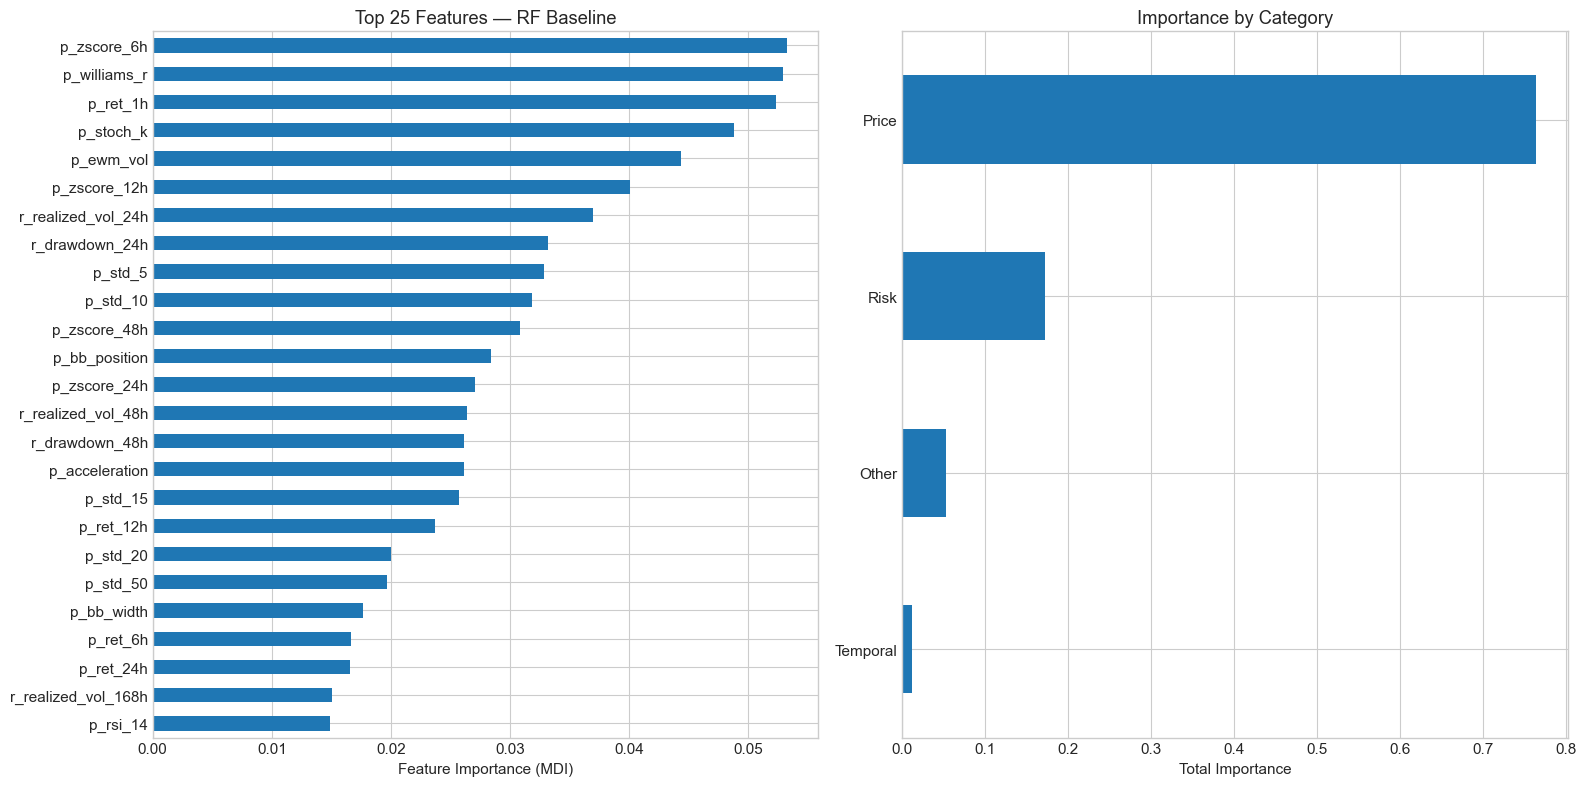

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

importance.head(25).plot(kind='barh', ax=axes[0])
axes[0].set_xlabel('Feature Importance (MDI)')
axes[0].set_title('Top 25 Features — RF Baseline')
axes[0].invert_yaxis()

cat_imp = {}
for cat, prefix in [('Price', 'p_'), ('Risk', 'r_'), ('Volume', 'v_'), ('Temporal', 't_')]:
    cols = [c for c in numeric_feats if c.startswith(prefix)]
    if cols:
        cat_imp[cat] = importance.reindex(cols).sum()
other = [c for c in numeric_feats if not c.startswith(('p_','r_','v_','t_'))]
if other:
    cat_imp['Other'] = importance.reindex(other).sum()

pd.Series(cat_imp).sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_xlabel('Total Importance')
axes[1].set_title('Importance by Category')

plt.tight_layout()
plt.show()

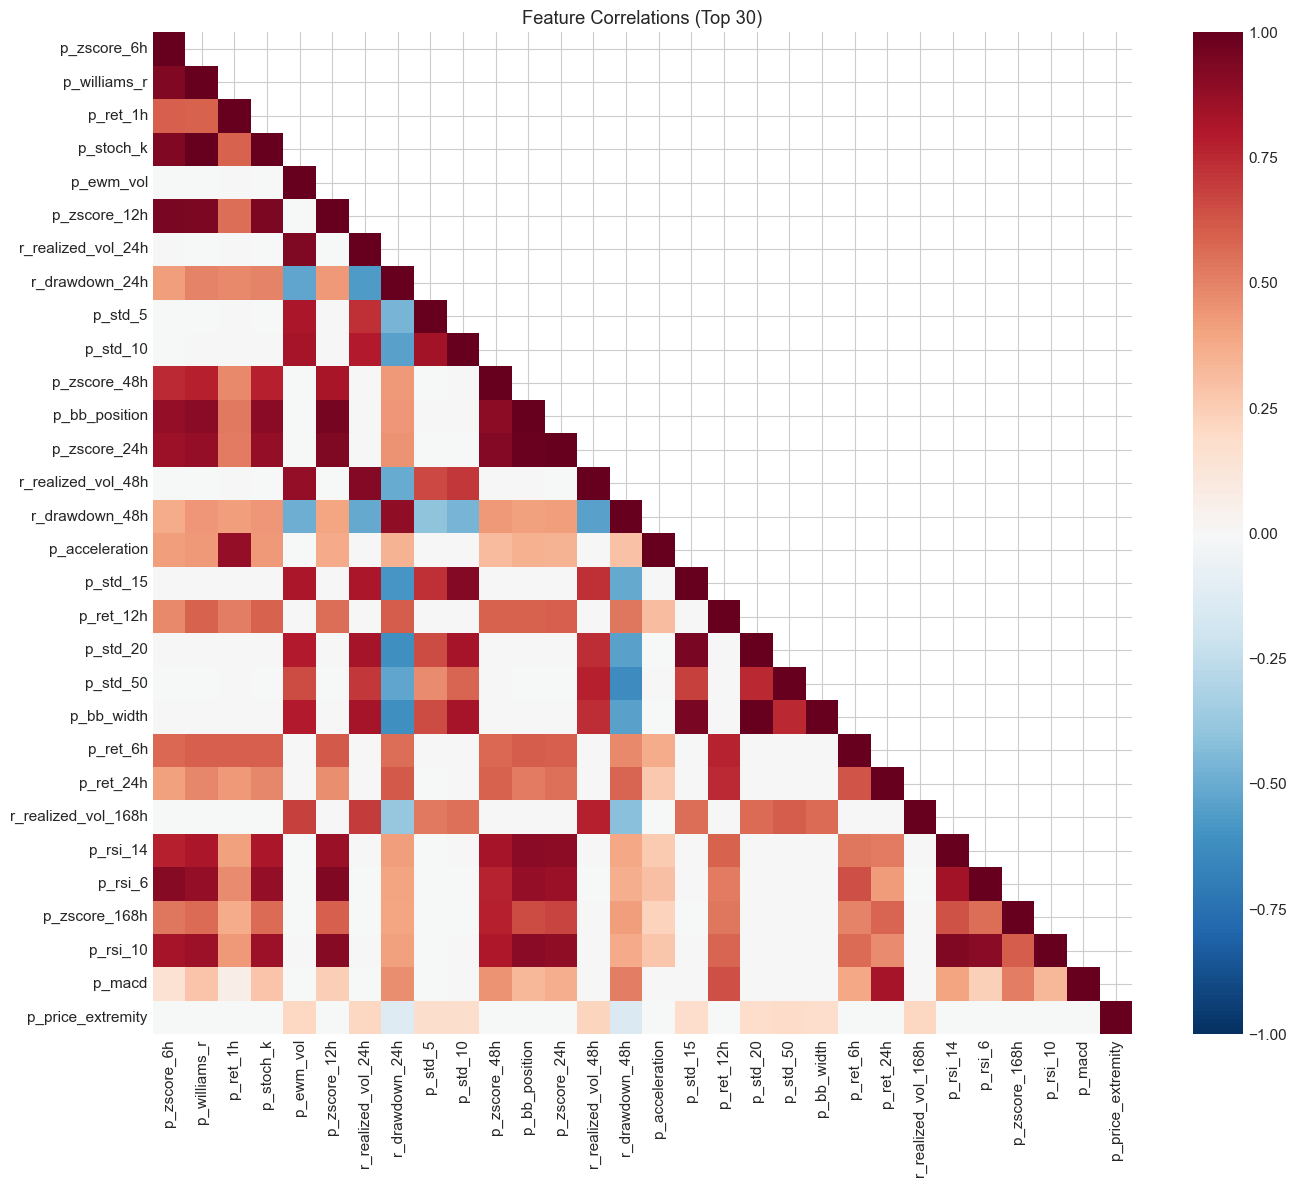

Highly correlated (|r|>0.9) — drop candidates for Phase 4:
  p_williams_r <-> p_stoch_k: r=1.000
  p_std_20 <-> p_bb_width: r=1.000
  p_bb_position <-> p_zscore_24h: r=0.988
  p_zscore_12h <-> p_bb_position: r=0.955
  p_std_15 <-> p_std_20: r=0.951
  p_std_15 <-> p_bb_width: r=0.951
  p_zscore_6h <-> p_zscore_12h: r=0.946
  p_williams_r <-> p_zscore_12h: r=0.938
  p_stoch_k <-> p_zscore_12h: r=0.938
  p_ewm_vol <-> r_realized_vol_24h: r=0.932
  p_zscore_12h <-> p_zscore_24h: r=0.931
  p_zscore_6h <-> p_williams_r: r=0.926
  p_zscore_6h <-> p_stoch_k: r=0.926
  p_rsi_14 <-> p_rsi_10: r=0.925
  p_zscore_12h <-> p_rsi_6: r=0.923
  p_zscore_48h <-> p_zscore_24h: r=0.918
  p_std_10 <-> p_std_15: r=0.918
  r_realized_vol_24h <-> r_realized_vol_48h: r=0.918
  p_zscore_12h <-> p_rsi_10: r=0.912
  p_zscore_6h <-> p_rsi_6: r=0.909
  p_rsi_6 <-> p_rsi_10: r=0.905
  p_williams_r <-> p_bb_position: r=0.901
  p_stoch_k <-> p_bb_position: r=0.901
  p_bb_position <-> p_rsi_14: r=0.901
  p_bb_position 

In [27]:
top30 = importance.head(30).index.tolist()
corr = feature_matrix[top30].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, xticklabels=True, yticklabels=True)
ax.set_title('Feature Correlations (Top 30)')
plt.tight_layout()
plt.show()

high_corr = [(top30[i], top30[j], abs(corr.iloc[i, j]))
             for i in range(len(top30)) for j in range(i+1, len(top30))
             if abs(corr.iloc[i, j]) > 0.9]
if high_corr:
    print('Highly correlated (|r|>0.9) — drop candidates for Phase 4:')
    for f1, f2, r in sorted(high_corr, key=lambda x: -x[2]):
        print(f'  {f1} <-> {f2}: r={r:.3f}')
else:
    print('No highly correlated pairs (>0.9) among top 30')

In [28]:
print('=' * 70)
print('PHASE 3 FEATURE ENGINEERING — SUMMARY')
print('=' * 70)

print(f'\n--- Sampling ---')
print(f'Tokens: {price_pivot.shape[1]}')
print(f'CUSUM events (h={H_CUSUM}): {n_total_events:,}')
print(f'Triple Barrier labels: {len(labels_df):,} (trgt={TRGT}, max_hours={MAX_HOURS})')
print(f'Fractional diff d={D_OPT:.2f}')

print(f'\n--- Feature Matrix ---')
print(f'Samples: {len(feature_matrix):,}')
print(f'Total features: {len(numeric_feats)}')
for cat, prefix in [('Price/Technical', 'p_'), ('Risk', 'r_'), ('Volume', 'v_'), ('Temporal', 't_')]:
    n = sum(1 for c in numeric_feats if c.startswith(prefix))
    print(f'  {cat}: {n}')
n_other = sum(1 for c in numeric_feats if not c.startswith(('p_','r_','v_','t_')))
print(f'  Other (cluster, maturity, NR, orderbook): {n_other}')

print(f'\n--- Labels ---')
for label, name in [(-1, 'SL'), (0, 'Vertical'), (1, 'TP')]:
    print(f'  {name}: {(labels_df["label"] == label).mean():.1%}')

print(f'\n--- Sample Weights (AFML) ---')
print(f'Range: [{feature_matrix.sample_weight.min():.3f}, {feature_matrix.sample_weight.max():.3f}]')

print(f'\n--- Baseline RF ---')
print(f'Val accuracy: {acc:.3f} (with AFML sample weights)')
print(f'Top 5: {list(importance.head(5).index)}')

print(f'\n--- Knowledge Applied ---')
print(f'[v] AFML: CUSUM filter, sample weights (co-events + time decay)')
print(f'[v] AFML: Fractional differentiation (d={D_OPT:.2f})')
print(f'[v] Triple Barrier paper: 33 tech features + PM-adapted barriers')
print(f'[v] Ernest Chan: MR z-scores, Bollinger, ADF verification')
print(f'[v] Matched Filter (Kang): S_MC and S_TV for whale flow')
print(f'[v] Kyle lambda: rolling regression price impact')
print(f'[v] NegRisk: sum deviation for arb signal')
print(f'[v] PM-specific: additive returns, price extremity, [0,1] bounds')

print(f'\n--- Saved ---')
print(f'data/features/feature_matrix_v2.parquet')
print(f'data/features/feature_meta_v2.json')

print(f'\n--- Next Steps (Phase 4: Modeling) ---')
print('1. XGBoost/LightGBM + Optuna tuning')
print('2. PurgedKFold (AFML, no lookahead bias)')
print('3. Feature selection: drop correlated + low-importance')
print('4. ResNet-LSTM (best from Triple Barrier paper)')
print('5. Calibration (Platt/isotonic)')
print('6. Meta-labeling for bet sizing')

PHASE 3 FEATURE ENGINEERING — SUMMARY

--- Sampling ---
Tokens: 665
CUSUM events (h=0.03): 43,604
Triple Barrier labels: 43,461 (trgt=0.05, max_hours=24)
Fractional diff d=0.00

--- Feature Matrix ---
Samples: 43,461
Total features: 63
  Price/Technical: 37
  Risk: 10
  Volume: 0
  Temporal: 6
  Other (cluster, maturity, NR, orderbook): 10

--- Labels ---
  SL: 40.4%
  Vertical: 19.3%
  TP: 40.4%

--- Sample Weights (AFML) ---
Range: [1.000, 1.000]

--- Baseline RF ---
Val accuracy: 0.505 (with AFML sample weights)
Top 5: ['p_zscore_6h', 'p_williams_r', 'p_ret_1h', 'p_stoch_k', 'p_ewm_vol']

--- Knowledge Applied ---
[v] AFML: CUSUM filter, sample weights (co-events + time decay)
[v] AFML: Fractional differentiation (d=0.00)
[v] Triple Barrier paper: 33 tech features + PM-adapted barriers
[v] Ernest Chan: MR z-scores, Bollinger, ADF verification
[v] Matched Filter (Kang): S_MC and S_TV for whale flow
[v] Kyle lambda: rolling regression price impact
[v] NegRisk: sum deviation for arb si